In [1]:
!pip install numpy pandas matplotlib scipy astropy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.constants import c
from astropy import units as u

In [2]:
file_path = "/content/Pantheon+SH0ES.dat"
data = pd.read_csv("Pantheon+SH0ES.dat", delim_whitespace=True, comment="#")

/tmp/ipython-input-2-948264487.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("Pantheon+SH0ES.dat", delim_whitespace=True, comment="#")


In [3]:
z = data["zHD"]

mu = data["m_b_corr"] + 19.244

mu_err = data["m_b_corr_err_DIAG"]


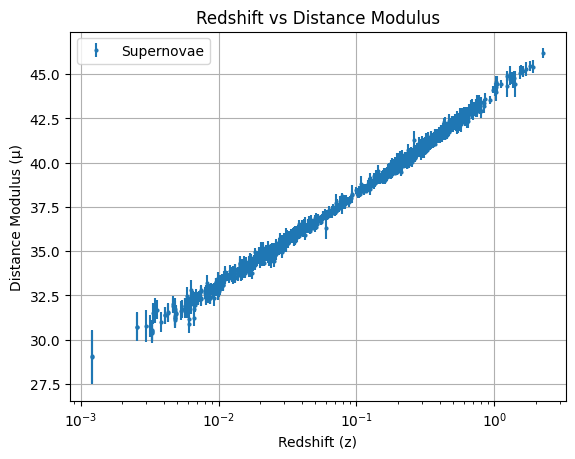

In [4]:
import matplotlib.pyplot as plt

plt.errorbar(z, mu, yerr=mu_err, fmt='o', markersize=2, label="Supernovae")
plt.xscale("log")
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (μ)")
plt.title("Redshift vs Distance Modulus")
plt.grid(True)
plt.legend()
plt.show()



Estimated Hubble constant (H0): 71.43 ± 0.27 km/s/Mpc


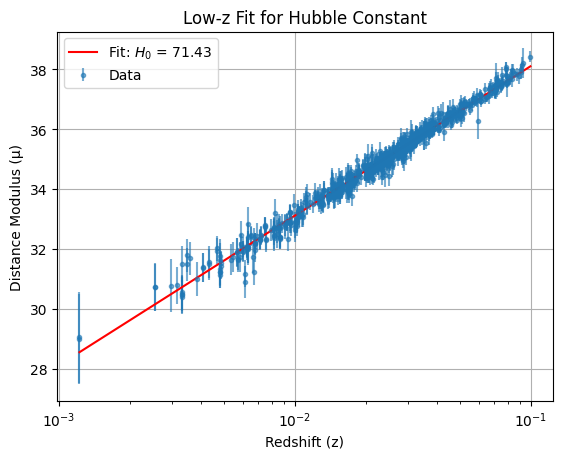

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

c = 299792.458

def distance_modulus_lowz(z, H0):
    d_L = (c * z) / H0
    mu = 5 * np.log10(d_L * 1e6) - 5
    return mu

mask = z < 0.1
z_fit = z[mask]
mu_fit = mu[mask]
mu_err_fit = mu_err[mask]

popt, pcov = curve_fit(distance_modulus_lowz, z_fit, mu_fit, sigma=mu_err_fit, absolute_sigma=True)
H0_est = popt[0]
H0_err = np.sqrt(np.diag(pcov))[0]

print(f"Estimated Hubble constant (H0): {H0_est:.2f} ± {H0_err:.2f} km/s/Mpc")

plt.errorbar(z_fit, mu_fit, yerr=mu_err_fit, fmt='.', label='Data', alpha=0.6)
z_line = np.linspace(min(z_fit), max(z_fit), 500)
plt.plot(z_line, distance_modulus_lowz(z_line, H0_est), color='red', label=f'Fit: $H_0$ = {H0_est:.2f}')
plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Distance Modulus (μ)')
plt.title('Low-z Fit for Hubble Constant')
plt.legend()
plt.grid(True)
plt.show()


From the full dataset, the hubble constant is estimated from

In [6]:
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.constants import c
import numpy as np

c_kms = c.to("km/s").value

def E(z, Omega_m):
    return np.sqrt(Omega_m * (1 + z)**3 + (1 - Omega_m))

def luminosity_distance(z, H0, Omega_m):
    integral, _ = quad(lambda z_prime: 1.0 / E(z_prime, Omega_m), 0, z)
    d_L = (1 + z) * (c_kms / H0) * integral
    return d_L

def mu_theory(z, H0, Omega_m):
    d_L = luminosity_distance(z, H0, Omega_m)
    return 5 * np.log10(d_L) + 25
print(mu_theory(0.5, 70, 0.3))

42.26118542154089


In [7]:
from scipy.optimize import curve_fit
import numpy as np

def mu_theory_vectorized(z, H0, Omega_m):
    return np.array([mu_theory(zi, H0, Omega_m) for zi in z])

p0 = [70, 0.3]

params, covariance = curve_fit(mu_theory_vectorized, z, mu, sigma=mu_err, p0=p0)

H0_fit, Omega_m_fit = params
H0_err, Omega_m_err = np.sqrt(np.diag(covariance))

print(f"Fitted H0 = {H0_fit:.2f} ± {H0_err:.2f} km/s/Mpc")
print(f"Fitted Omega_m = {Omega_m_fit:.3f} ± {Omega_m_err:.3f}")


print(f"Fitted H0 = {H0_fit:.2f} ± {H0_err:.2f} km/s/Mpc")
print(f"Fitted Omega_m = {Omega_m_fit:.3f} ± {Omega_m_err:.3f}")


Fitted H0 = 73.28 ± 0.17 km/s/Mpc
Fitted Omega_m = 0.351 ± 0.012
Fitted H0 = 73.28 ± 0.17 km/s/Mpc
Fitted Omega_m = 0.351 ± 0.012


In [8]:
from scipy.integrate import quad
from astropy.constants import c
import numpy as np

# E(z) already defined earlier
def E(z, Omega_m):
    return np.sqrt(Omega_m * (1 + z)**3 + (1 - Omega_m))

# Age of universe in Gyr
def age_of_universe(H0, Omega_m):
    # H0 in km/s/Mpc -> H0_SI in s⁻¹
    H0_SI = H0 * 1000 / (3.086e22)  # 1 Mpc = 3.086e22 meters
    # Integrate from z = 0 to a large number (simulate ∞)
    integral, _ = quad(lambda z: 1.0 / ((1 + z) * E(z, Omega_m)), 0, np.inf)
    age_sec = integral / H0_SI  # in seconds
    age_gyr = age_sec / (3600 * 24 * 365.25 * 1e9)  # convert to Gyr
    return age_gyr
t0 = age_of_universe(H0_fit, Omega_m_fit)
print(f"Estimated age of Universe: {t0:.2f} Gyr")

Estimated age of Universe: 12.31 Gyr


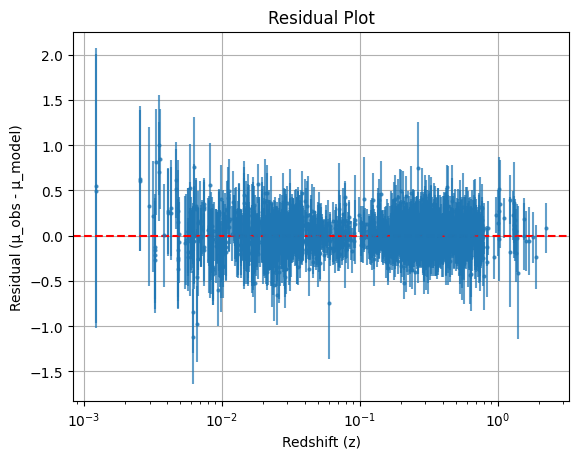

In [9]:
# Write the code to find residual by computing mu_theory and then plot
# Use vectorized version of your theoretical model
def mu_theory_vectorized(z, H0, Omega_m):
    return np.array([mu_theory(zi, H0, Omega_m) for zi in z])

# Compute model values using the best-fit parameters
mu_model = mu_theory_vectorized(z, H0_fit, Omega_m_fit)
residuals = mu - mu_model
import matplotlib.pyplot as plt

plt.errorbar(z, residuals, yerr=mu_err, fmt='o', markersize=2, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Redshift (z)")
plt.ylabel("Residual (μ_obs - μ_model)")
plt.title("Residual Plot")
plt.xscale("log")
plt.grid(True)
plt.show()

Fitted H0 (fixed Ωm = 0.3): 73.84 ± 0.11 km/s/Mpc


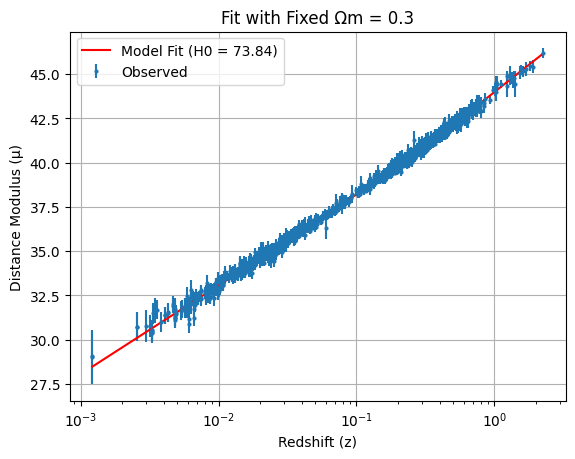

In [10]:
def mu_fixed_Om(z, H0):
    return mu_theory(z, H0, Omega_m=0.3)
# Fix Omega_m = 0.3
Omega_m_fixed = 0.3

def mu_theory_fixed_omega(z, H0):
    return np.array([mu_theory(zi, H0, Omega_m_fixed) for zi in z])
from scipy.optimize import curve_fit

# Initial guess for H0
p0 = [70]

# Perform the fit (now only H0 is varied)
params, cov = curve_fit(mu_theory_fixed_omega, z, mu, sigma=mu_err, p0=p0)

# Extract fitted H0 and uncertainty
H0_fit_fixed = params[0]
H0_err_fixed = np.sqrt(cov[0][0])

# Print the result
print(f"Fitted H0 (fixed Ωm = 0.3): {H0_fit_fixed:.2f} ± {H0_err_fixed:.2f} km/s/Mpc")
mu_model_fixed = mu_theory_fixed_omega(z, H0_fit_fixed)
plt.errorbar(z, mu, yerr=mu_err, fmt='o', markersize=2, label="Observed")
plt.plot(z, mu_model_fixed, color='red', label=f"Model Fit (H0 = {H0_fit_fixed:.2f})")
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (μ)")
plt.xscale("log")
plt.legend()
plt.grid(True)
plt.title("Fit with Fixed Ωm = 0.3")
plt.show()

In [11]:
# Split the data for the three columns and do the fitting again and see
Omega_m_fixed = 0.3

def mu_theory_fixed_omega(z, H0):
    return np.array([mu_theory(zi, H0, Omega_m_fixed) for zi in z])
# Masks for splitting
low_z_mask = z < 0.1
high_z_mask = z >= 0.1

# Low-z data
z_low = z[low_z_mask]
mu_low = mu[low_z_mask]
mu_err_low = mu_err[low_z_mask]

# High-z data
z_high = z[high_z_mask]
mu_high = mu[high_z_mask]
mu_err_high = mu_err[high_z_mask]
# Fit H0 for low-z
params_low, cov_low = curve_fit(mu_theory_fixed_omega, z_low, mu_low, sigma=mu_err_low, p0=[70])
H0_low = params_low[0]
H0_low_err = np.sqrt(cov_low[0][0])
# Fit H0 for high-z
params_high, cov_high = curve_fit(mu_theory_fixed_omega, z_high, mu_high, sigma=mu_err_high, p0=[70])
H0_high = params_high[0]
H0_high_err = np.sqrt(cov_high[0][0])
print(f"Low-z (z < 0.1) H0 = {H0_low:.2f} ± {H0_low_err:.2f} km/s/Mpc")
print(f"High-z (z ≥ 0.1) H0 = {H0_high:.2f} ± {H0_high_err:.2f} km/s/Mpc")

Low-z (z < 0.1) H0 = 73.31 ± 0.19 km/s/Mpc
High-z (z ≥ 0.1) H0 = 74.16 ± 0.14 km/s/Mpc
